In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("netflix_titles_clean.csv")

# Display first five rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Movie      6131
TV Show    2676
Name: type, dtype: int64
Movie      69.615079
TV Show    30.384921
Name: type, dtype: float64


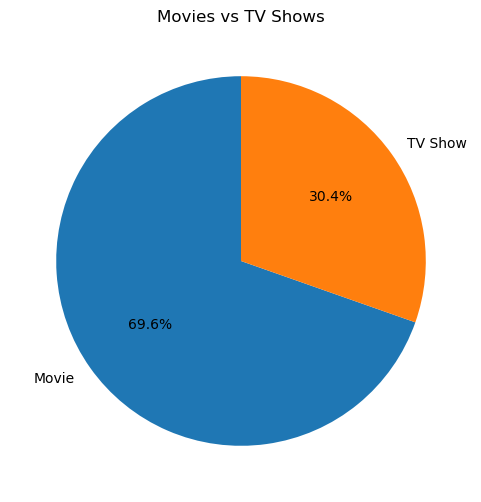

In [4]:
#1. What is the ratio of Movies to TV Shows?

content_ratio = df['type'].value_counts()

print(content_ratio)

# Percentage
ratio = (content_ratio / content_ratio.sum()) * 100
print(ratio)

# Visualization
plt.figure(figsize=(6,6))
plt.pie(
    content_ratio,
    labels=content_ratio.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Movies vs TV Shows")
plt.show()

United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: country, dtype: int64


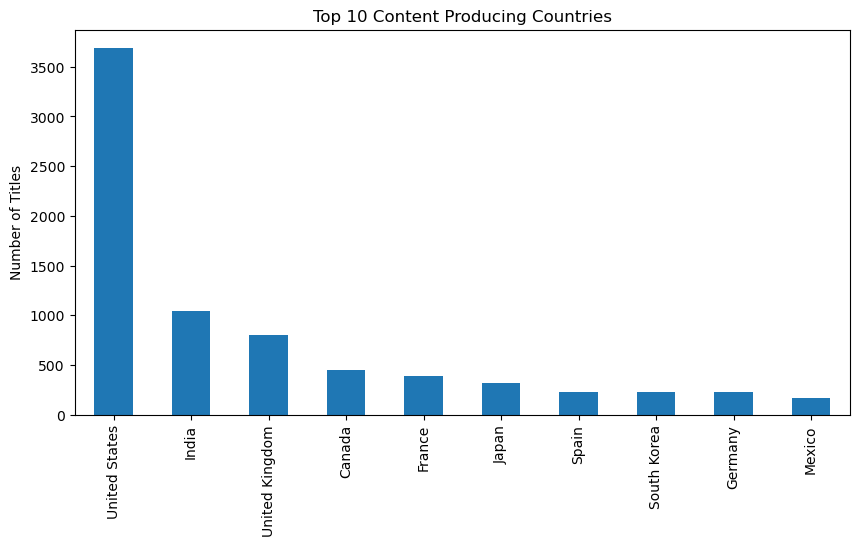

In [5]:
#2. Which countries produce the most Netflix content?

country_count = (
    df['country']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
)

print(country_count.head(10))

country_count.head(10).plot(
    kind='bar',
    figsize=(10,5),
    title='Top 10 Content Producing Countries'
)

plt.ylabel("Number of Titles")
plt.show()

Year: 2018
Titles: 1147


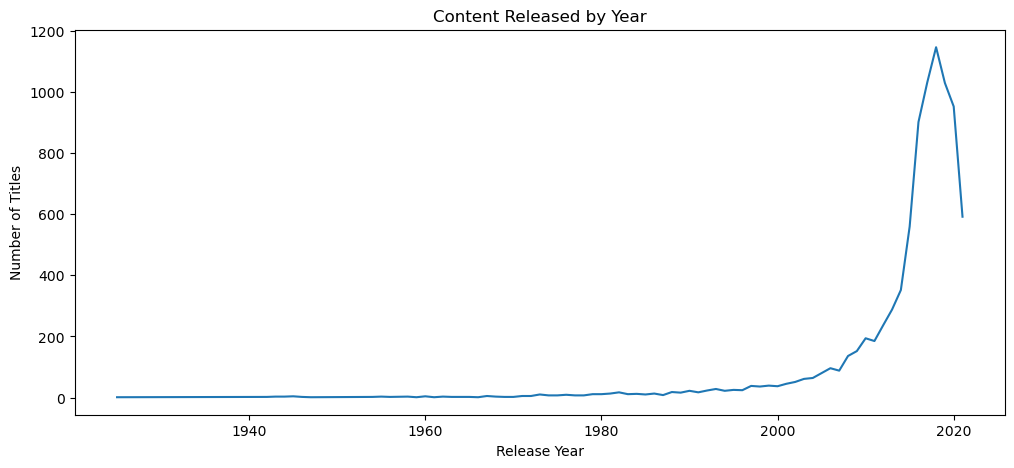

In [6]:
#3. Which year had the highest number of content releases?

release_year = df['release_year'].value_counts().sort_index()

highest_release = release_year.idxmax()

print("Year:", highest_release)
print("Titles:", release_year.max())

release_year.plot(figsize=(12,5))
plt.title("Content Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: date_added, dtype: int64

Highest Year: 2019.0


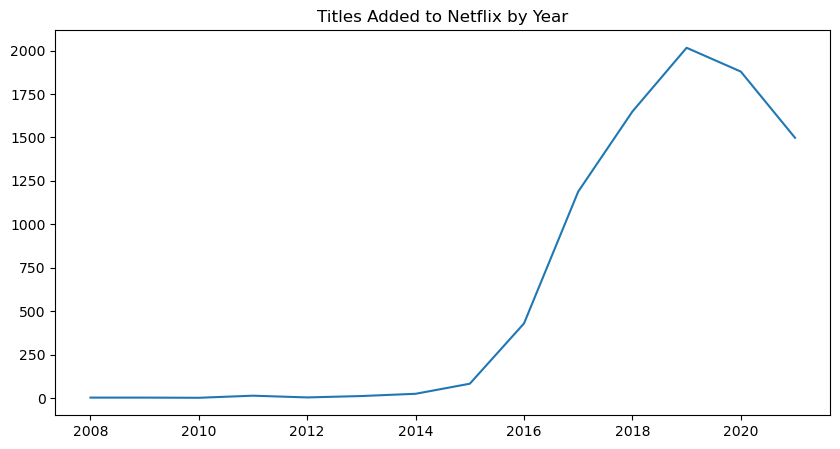

In [6]:
#4. Which year did Netflix add the most titles?

df['date_added'] = pd.to_datetime(df['date_added'])

added_year = df['date_added'].dt.year.value_counts().sort_index()

print(added_year)

print("\nHighest Year:", added_year.idxmax())

added_year.plot(figsize=(10,5))
plt.title("Titles Added to Netflix by Year")
plt.show()

International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: listed_in, dtype: int64


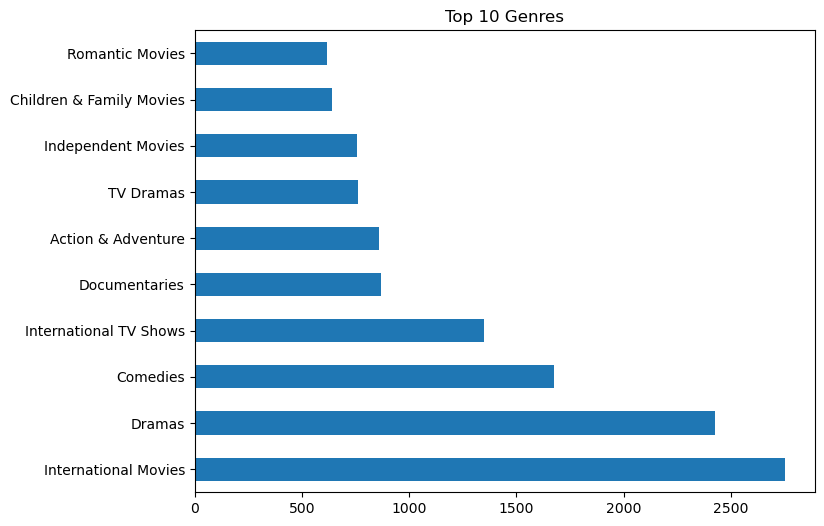

In [7]:
#5. What are the Top 10 Most Common Genres?

genres = (
    df['listed_in']
    .str.split(', ')
    .explode()
    .value_counts()
)

print(genres.head(10))

genres.head(10).plot(
    kind='barh',
    figsize=(8,6)
)

plt.title("Top 10 Genres")
plt.show()

TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: rating, dtype: int64


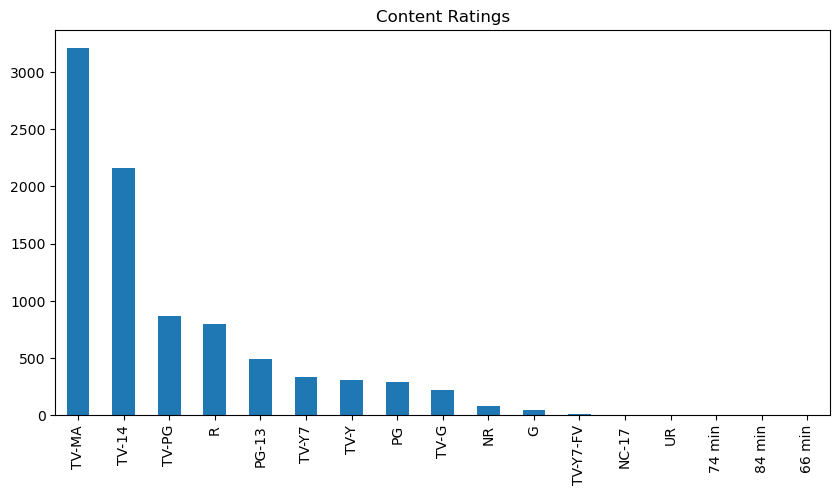

In [8]:
#6. What are the Most Common Content Ratings?

ratings = df['rating'].value_counts()

print(ratings)

ratings.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Content Ratings")
plt.show()

In [12]:
#7. Average Movie Duration

movies = df[df['type'] == 'Movie'].copy()

# Remove rows with missing duration
movies = movies.dropna(subset=['duration'])

# Remove ' min' and convert to integer
movies['duration'] = (
    movies['duration']
    .str.replace(' min', '', regex=False)
    .astype(int)
)

average_duration = movies['duration'].mean()

print(f"Average Movie Duration: {average_duration:.2f} minutes")

Average Movie Duration: 99.58 minutes


Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Jay Chapman            12
Youssef Chahine        12
Martin Scorsese        12
Name: director, dtype: int64


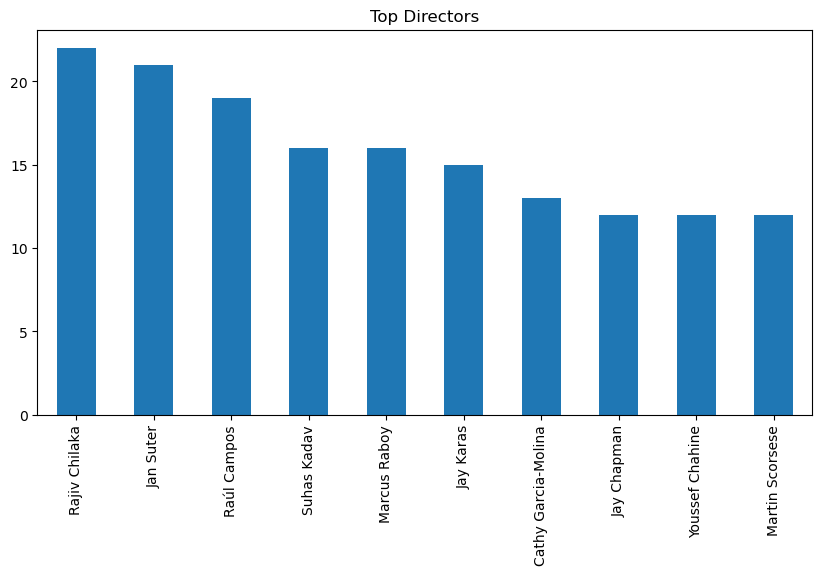

In [13]:
#8. Which Directors Have the Highest Number of Titles?

directors = (
    df['director']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
)

print(directors.head(10))

directors.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Directors")
plt.show()

Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Paresh Rawal        28
Name: cast, dtype: int64


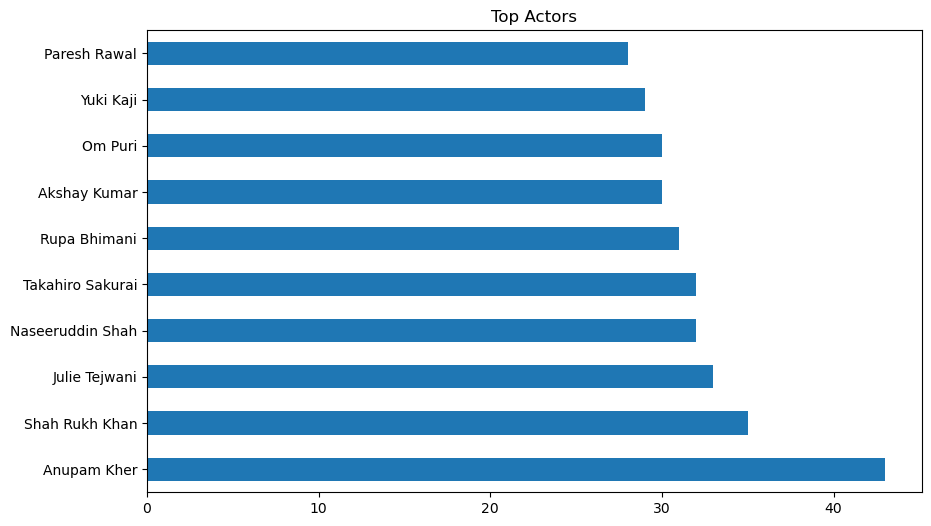

In [14]:
#9. Which Actors Appear Most Frequently?

actors = (
    df['cast']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
)

print(actors.head(10))

actors.head(10).plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Top Actors")
plt.show()

In [15]:
#10. Which Countries Have the Highest Proportion of TV Shows vs Movies?

country_type = (
    df.assign(country=df['country'].str.split(', '))
      .explode('country')
      .groupby(['country', 'type'])
      .size()
      .unstack(fill_value=0)
)

country_type['TV Show Ratio'] = (
    country_type['TV Show'] /
    (country_type['Movie'] + country_type['TV Show'])
)

country_type = country_type.sort_values(
    by='TV Show Ratio',
    ascending=False
)

print(country_type.head(10))

type         Movie  TV Show  TV Show Ratio
country                                   
Belarus          0        1       1.000000
Cuba             0        1       1.000000
Cyprus           0        1       1.000000
Puerto Rico      0        1       1.000000
Azerbaijan       0        1       1.000000
Taiwan          19       70       0.786517
South Korea     61      170       0.735931
Ukraine          1        2       0.666667
Japan          119      199       0.625786
Colombia        20       32       0.615385
